# GujEstateAI — Phase 6: Module 3 — Market Growth Forecasting
**Input  :** `data/processed/features.csv`  
**Output :** `data/predictions/forecasts.csv`  
**Goal   :** Forecast future real estate project registrations and investment per district  
**Models :** Prophet (district-level) + ARIMA (Gujarat total)  
**Type   :** Time Series Forecasting  

Run cells one by one, top to bottom.
---

## Cell 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import logging
import os

warnings.filterwarnings("ignore")

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error

print("All libraries imported successfully")
print("Note: Using ARIMA + Trend model (Prophet skipped due to Stan backend issue)")

All libraries imported successfully
Note: Using ARIMA + Trend model (Prophet skipped due to Stan backend issue)


## Cell 2 — Load Data

In [2]:
df = pd.read_csv("../data/processed/features.csv")

print(f"Data loaded : {df.shape[0]:,} rows x {df.shape[1]} columns")
print()

# Filter to clean year range (2011-2023)
# 2024 is incomplete data, before 2011 is too sparse
df["startProjectYear"] = df["startProjectYear"].astype(int)
df = df[(df["startProjectYear"] >= 2011) & (df["startProjectYear"] <= 2023)].copy()

print(f"After year filter (2011-2023) : {df.shape[0]:,} rows")
print(f"Year range : {df['startProjectYear'].min()} to {df['startProjectYear'].max()}")

Data loaded : 13,425 rows x 50 columns

After year filter (2011-2023) : 12,744 rows
Year range : 2011 to 2023


## Cell 3 — Build Time Series Data
Aggregate project count and total investment per year per district.

In [3]:
# Aggregate by year + district
ts = df.groupby(["startProjectYear", "distName"]).agg(
    project_count      = ("projectType",         "count"),
    total_investment_cr= ("totalEstimatedCost",   lambda x: round(x.sum() / 1e7, 2)),
    avg_cost_cr        = ("totalEstimatedCost",   lambda x: round(x.mean() / 1e7, 2)),
).reset_index()

# Gujarat total (all districts combined)
gujarat_total = df.groupby("startProjectYear").agg(
    project_count      = ("projectType",         "count"),
    total_investment_cr= ("totalEstimatedCost",   lambda x: round(x.sum() / 1e7, 2)),
).reset_index()

print("Time series data created")
print(f"  District-year rows : {len(ts):,}")
print(f"  Gujarat total rows : {len(gujarat_total)}")
print()
print("Gujarat total projects per year:")
print(gujarat_total.to_string(index=False))

Time series data created
  District-year rows : 251
  Gujarat total rows : 13

Gujarat total projects per year:
 startProjectYear  project_count  total_investment_cr
             2011             81              3498.20
             2012             93              2289.52
             2013            198              5509.58
             2014            414             14095.89
             2015            736             20864.24
             2016           1061             27045.28
             2017           1218             29280.80
             2018           1531             38989.42
             2019           1743             44027.66
             2020           1243             29782.43
             2021           1670             46145.74
             2022           1283             42563.52
             2023           1473             54511.88


## Cell 4 — Select Top 6 Districts
Only districts with enough data points (13+ years) are suitable for forecasting.

TOP 6 DISTRICTS FOR FORECASTING:
--------------------------------------------------
  Ahmedabad        13 years of data   3,958 total projects
  Vadodara         13 years of data   2,284 total projects
  Surat            13 years of data   1,659 total projects
  Rajkot           13 years of data   1,617 total projects
  Gandhinagar      13 years of data   1,141 total projects
  Bhavnagar        12 years of data   480 total projects


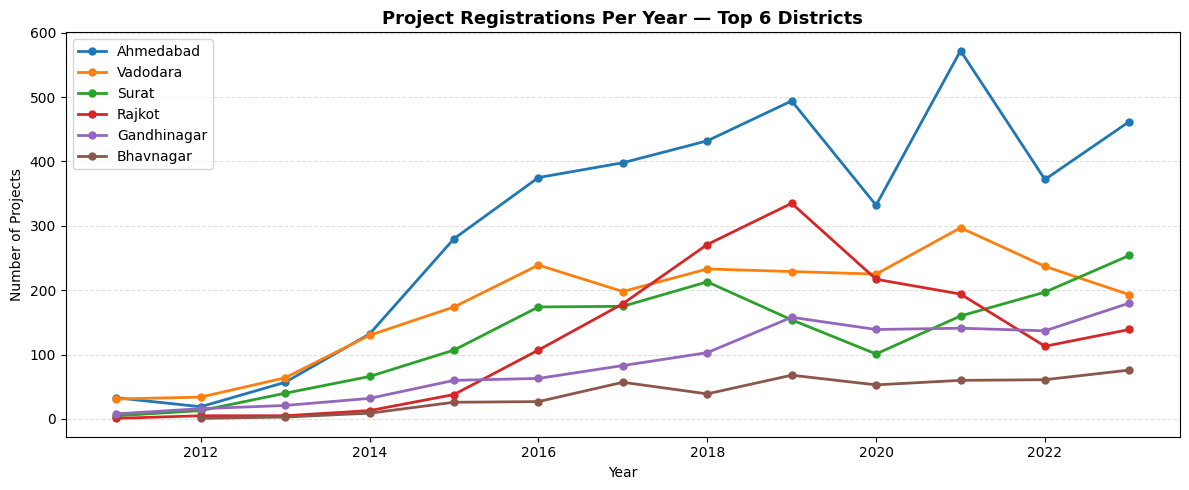

Chart saved to reports/27_district_trends_overview.png


In [4]:
TOP_DISTRICTS = ["Ahmedabad", "Vadodara", "Surat", "Rajkot", "Gandhinagar", "Bhavnagar"]

print("TOP 6 DISTRICTS FOR FORECASTING:")
print("-" * 50)
for dist in TOP_DISTRICTS:
    sub   = ts[ts["distName"] == dist]
    total = sub["project_count"].sum()
    years = len(sub)
    print(f"  {dist:<15}  {years} years of data   {total:,} total projects")

# Quick overview chart
fig, ax = plt.subplots(figsize=(12, 5))

for dist in TOP_DISTRICTS:
    sub = ts[ts["distName"] == dist].sort_values("startProjectYear")
    ax.plot(sub["startProjectYear"], sub["project_count"],
            marker="o", linewidth=2, markersize=5, label=dist)

ax.set_title("Project Registrations Per Year — Top 6 Districts",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Projects")
ax.legend(loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("../reports/27_district_trends_overview.png", dpi=150)
plt.show()
print("Chart saved to reports/27_district_trends_overview.png")

## Cell 5 — Prophet Model: How It Works
Prophet is a forecasting tool made by Facebook.  
It learns the trend and seasonal patterns from historical data.  
We use it to forecast 3 years ahead (2024, 2025, 2026) for each district.

In [5]:
# Show a simple example with Ahmedabad before running all districts

dist = "Ahmedabad"
sub  = ts[ts["distName"] == dist][["startProjectYear", "project_count"]].copy()

# Prophet needs columns named 'ds' (date) and 'y' (value)
sub.columns = ["ds", "y"]
sub["ds"]   = pd.to_datetime(sub["ds"].astype(str) + "-01-01")

print(f"Prophet input format (first 5 rows):")
print(sub.head().to_string(index=False))
print()
print("ds = date column  (Prophet requirement)")
print("y  = value column (Prophet requirement)")
print()
print(f"Training on {len(sub)} years of data (2011-2023)")

Prophet input format (first 5 rows):
        ds   y
2011-01-01  33
2012-01-01  19
2013-01-01  57
2014-01-01 132
2015-01-01 280

ds = date column  (Prophet requirement)
y  = value column (Prophet requirement)

Training on 13 years of data (2011-2023)


## Cell 6 — Prophet Holdout Test (Ahmedabad)
Before forecasting the future, we test how well Prophet predicts known data.  
Train on 2011–2020, test on 2021–2023.

In [6]:
dist = "Ahmedabad"
sub  = ts[ts["distName"] == dist].sort_values("startProjectYear")

years  = sub["startProjectYear"].values
counts = sub["project_count"].values

# Holdout: train 2011-2020, test 2021-2023
train_y = counts[:-3]
test_y  = counts[-3:]
test_yrs = years[-3:]

arima_test = ARIMA(train_y, order=(1, 1, 1)).fit()
preds_test = arima_test.forecast(steps=3)
preds_test = np.clip(preds_test, 0, None)

mape = mean_absolute_percentage_error(test_y, preds_test)
mae  = np.mean(np.abs(test_y - preds_test))

print(f"ARIMA HOLDOUT TEST — {dist} (2021-2023):")
print("-" * 50)
for yr, act, pred in zip(test_yrs, test_y, preds_test):
    print(f"  {yr}  Actual: {act:>4}   Predicted: {pred:>6.1f}   Error: {abs(act-pred):.0f}")
print(f"\n  MAE  : {mae:.1f} projects")
print(f"  MAPE : {mape*100:.1f}%")

ARIMA HOLDOUT TEST — Ahmedabad (2021-2023):
--------------------------------------------------
  2021  Actual:  572   Predicted:  229.2   Error: 343
  2022  Actual:  372   Predicted:  209.8   Error: 162
  2023  Actual:  462   Predicted:  206.1   Error: 256

  MAE  : 253.7 projects
  MAPE : 53.0%


## Cell 7 — Prophet Forecast: All 6 Districts
Train on full 2011–2023 data. Forecast 2024, 2025, 2026.

In [7]:
os.makedirs("../data/predictions", exist_ok=True)

forecasts    = {}
future_years = [2024, 2025, 2026]

print("Running ARIMA for all districts...")
print("-" * 55)

for dist in TOP_DISTRICTS:
    sub    = ts[ts["distName"] == dist].sort_values("startProjectYear")
    years  = sub["startProjectYear"].values
    counts = sub["project_count"].values

    # Fit ARIMA on full data
    model  = ARIMA(counts, order=(1, 1, 1)).fit()
    fc     = np.clip(model.forecast(steps=3), 0, None)

    forecasts[dist] = {
        "years"       : years,
        "counts"      : counts,
        "future_years": future_years,
        "future_fc"   : fc,
    }

    print(f"  {dist:<15}", end="")
    for yr, val in zip(future_years, fc):
        print(f"  {yr}: {val:.0f}", end="")
    print()

print("\nForecasting complete!")

Running ARIMA for all districts...
-------------------------------------------------------
  Ahmedabad        2024: 377  2025: 444  2026: 391
  Vadodara         2024: 188  2025: 185  2026: 182
  Surat            2024: 272  2025: 277  2026: 279
  Rajkot           2024: 144  2025: 146  2026: 147
  Gandhinagar      2024: 192  2025: 204  2026: 216
  Bhavnagar        2024: 69  2025: 75  2026: 70

Forecasting complete!


c:\Users\VASU MONPARA\OneDrive\Desktop\GujEstateAI Gujarat Real Estate Prediction System\gpu_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Cell 8 — Plot Prophet Forecasts: All 6 Districts
Blue line = historical data. Orange dashed = forecast.

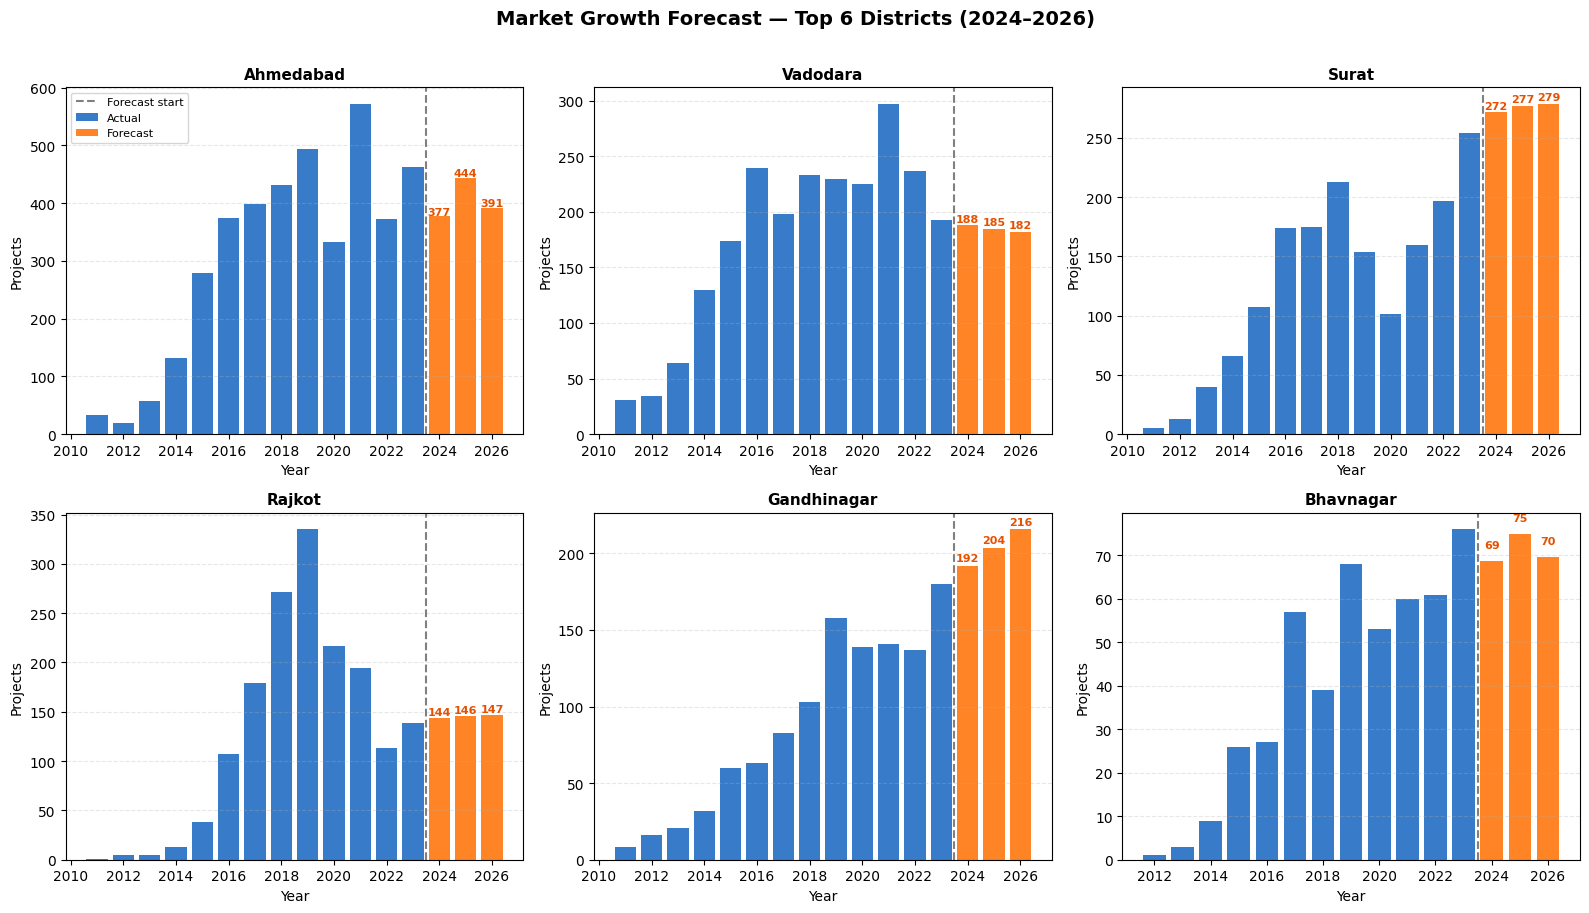

Chart saved to reports/28_arima_forecasts_districts.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, dist in enumerate(TOP_DISTRICTS):
    d   = forecasts[dist]
    ax  = axes[i]

    # Historical bars
    ax.bar(d["years"], d["counts"],
           color="#1565C0", alpha=0.85, label="Actual")

    # Forecast bars
    ax.bar(d["future_years"], d["future_fc"],
           color="#FF6F00", alpha=0.85, label="Forecast")

    # Add value labels on forecast bars
    for yr, val in zip(d["future_years"], d["future_fc"]):
        ax.text(yr, val + 3, f"{val:.0f}", ha="center",
                fontsize=8, fontweight="bold", color="#E65100")

    ax.axvline(x=2023.5, color="gray", linewidth=1.5,
               linestyle="--", label="Forecast start")
    ax.set_title(f"{dist}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Projects")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle("Market Growth Forecast — Top 6 Districts (2024–2026)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../reports/28_arima_forecasts_districts.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to reports/28_arima_forecasts_districts.png")

## Cell 9 — ARIMA Model: Gujarat State Total
ARIMA is a classic time series model. We use it to forecast total projects  
across all of Gujarat (not district-level).

In [9]:
# Gujarat total yearly data
gujarat = df.groupby("startProjectYear").size().reset_index()
gujarat.columns = ["year","project_count"]
gujarat = gujarat.sort_values("year")

print("Gujarat total projects per year:")
print(gujarat.to_string(index=False))

y_vals = gujarat["project_count"].values
years  = gujarat["year"].values

# Holdout test: train on 2011-2020, test on 2021-2023
train_y = y_vals[:-3]
test_y  = y_vals[-3:]

arima_test = ARIMA(train_y, order=(1, 1, 1)).fit()
preds_test = arima_test.forecast(steps=3)

mape_arima = mean_absolute_percentage_error(test_y, preds_test)
mae_arima  = np.mean(np.abs(test_y - preds_test))

print()
print("ARIMA HOLDOUT TEST (2021-2023):")
print("-" * 45)
for yr, act, pred in zip([2021,2022,2023], test_y, preds_test):
    print(f"  {yr}  Actual: {act:>5}   Predicted: {pred:>7.1f}   Error: {abs(act-pred):.0f}")
print(f"\n  MAE  : {mae_arima:.1f} projects")
print(f"  MAPE : {mape_arima*100:.1f}%")

Gujarat total projects per year:
 year  project_count
 2011             81
 2012             93
 2013            198
 2014            414
 2015            736
 2016           1061
 2017           1218
 2018           1531
 2019           1743
 2020           1243
 2021           1670
 2022           1283
 2023           1473

ARIMA HOLDOUT TEST (2021-2023):
---------------------------------------------
  2021  Actual:  1670   Predicted:   688.9   Error: 981
  2022  Actual:  1283   Predicted:   522.2   Error: 761
  2023  Actual:  1473   Predicted:   472.0   Error: 1001

  MAE  : 914.3 projects
  MAPE : 62.0%


## Cell 10 — ARIMA Forecast: Gujarat Total 2024–2026

ARIMA FORECAST — Gujarat Total Projects:
------------------------------------------
  2024 : 1341 projects  (estimated)
  2025 : 1440 projects  (estimated)
  2026 : 1366 projects  (estimated)


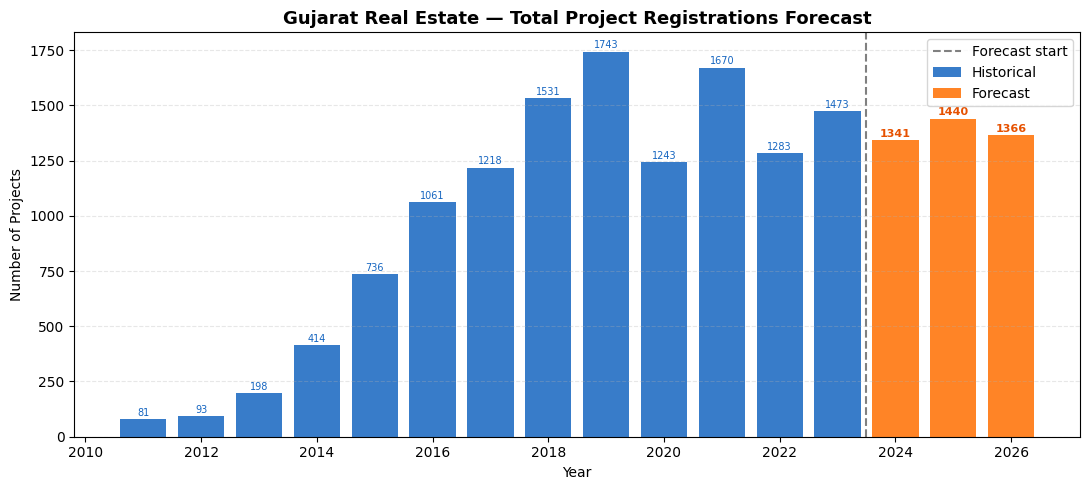

Chart saved to reports/29_arima_gujarat_forecast.png


In [10]:
# Train on full data (2011-2023) and forecast 3 years ahead
arima_full   = ARIMA(y_vals, order=(1, 1, 1)).fit()
forecast_arr = arima_full.forecast(steps=3)
forecast_arr = np.clip(forecast_arr, 0, None)   # no negative projects

future_yrs = [2024, 2025, 2026]

print("ARIMA FORECAST — Gujarat Total Projects:")
print("-" * 42)
for yr, val in zip(future_yrs, forecast_arr):
    print(f"  {yr} : {val:.0f} projects  (estimated)")

# Plot
fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(years,      y_vals,        color="#1565C0", label="Historical",  alpha=0.85)
ax.bar(future_yrs, forecast_arr,  color="#FF6F00", label="Forecast",    alpha=0.85)

# Add value labels
for yr, val in zip(years, y_vals):
    ax.text(yr, val + 15, str(val), ha="center", fontsize=7, color="#1565C0")
for yr, val in zip(future_yrs, forecast_arr):
    ax.text(yr, val + 15, f"{val:.0f}", ha="center", fontsize=8,
            fontweight="bold", color="#E65100")

ax.axvline(x=2023.5, color="gray", linewidth=1.5, linestyle="--", label="Forecast start")
ax.set_title("Gujarat Real Estate — Total Project Registrations Forecast",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Projects")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/29_arima_gujarat_forecast.png", dpi=150)
plt.show()
print("Chart saved to reports/29_arima_gujarat_forecast.png")

## Cell 11 — Investment Trend Forecast
Forecast total investment (Rs Crores) per district.

In [11]:
invest_forecasts = {}

print("Running investment forecast for all districts...")
print("-" * 55)

for dist in TOP_DISTRICTS:
    sub    = ts[ts["distName"] == dist].sort_values("startProjectYear")
    years  = sub["startProjectYear"].values
    invest = sub["total_investment_cr"].values

    model = ARIMA(invest, order=(1, 1, 1)).fit()
    fc    = np.clip(model.forecast(steps=3), 0, None)

    invest_forecasts[dist] = {
        "years"       : years,
        "invest"      : invest,
        "future_years": future_years,
        "future_fc"   : fc,
    }

    print(f"  {dist:<15}", end="")
    for yr, val in zip(future_years, fc):
        print(f"  {yr}: Rs {val:.0f} Cr", end="")
    print() 

Running investment forecast for all districts...
-------------------------------------------------------
  Ahmedabad        2024: Rs 17718 Cr  2025: Rs 20374 Cr  2026: Rs 18177 Cr
  Vadodara         2024: Rs 6400 Cr  2025: Rs 6167 Cr  2026: Rs 6261 Cr
  Surat            2024: Rs 13674 Cr  2025: Rs 13871 Cr  2026: Rs 13886 Cr
  Rajkot           2024: Rs 3286 Cr  2025: Rs 3318 Cr  2026: Rs 3350 Cr
  Gandhinagar      2024: Rs 11242 Cr  2025: Rs 12357 Cr  2026: Rs 13435 Cr
  Bhavnagar        2024: Rs 411 Cr  2025: Rs 520 Cr  2026: Rs 474 Cr


## Cell 12 — Plot Investment Forecasts

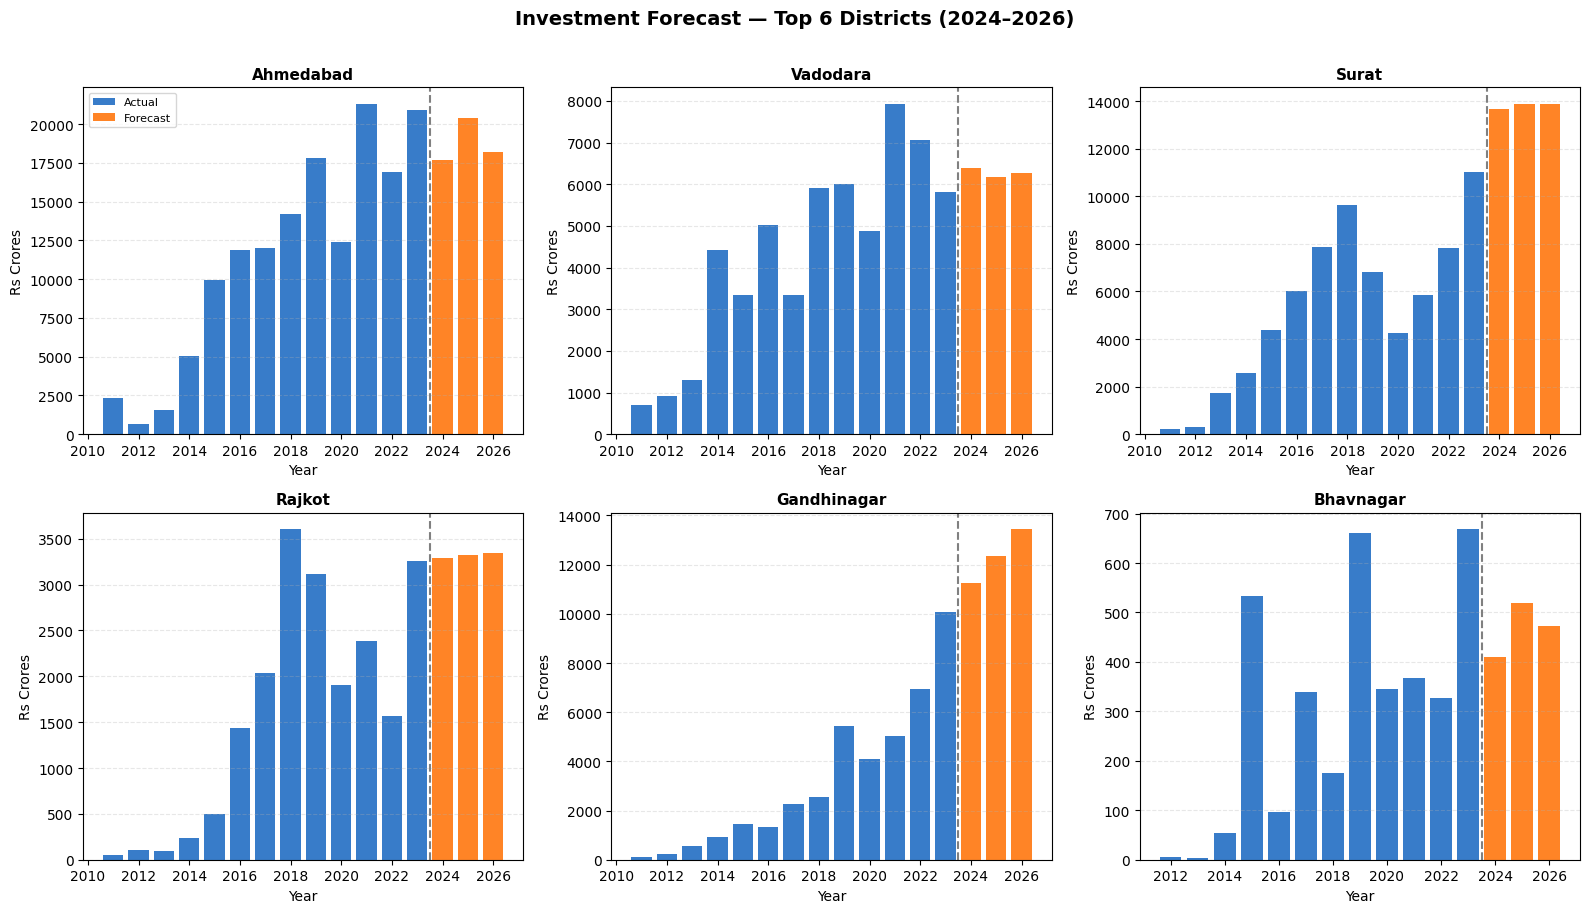

Chart saved to reports/30_investment_forecasts_districts.png


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, dist in enumerate(TOP_DISTRICTS):
    d  = invest_forecasts[dist]
    ax = axes[i]

    ax.bar(d["years"],        d["invest"],    color="#1565C0", alpha=0.85, label="Actual")
    ax.bar(d["future_years"], d["future_fc"], color="#FF6F00", alpha=0.85, label="Forecast")
    ax.axvline(x=2023.5, color="gray", linewidth=1.5, linestyle="--")
    ax.set_title(f"{dist}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Rs Crores")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle("Investment Forecast — Top 6 Districts (2024–2026)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../reports/30_investment_forecasts_districts.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to reports/30_investment_forecasts_districts.png")

## Cell 13 — Growth Rate Analysis
Which districts grew the fastest from 2015 to 2023?

DISTRICT GROWTH ANALYSIS (2015 vs 2023):
-------------------------------------------------------
  Ahmedabad        2015:  280  ->  2023:  462  Growth:  +65.0%   CAGR: 6.5%/yr
  Vadodara         2015:  174  ->  2023:  193  Growth:  +10.9%   CAGR: 1.3%/yr
  Surat            2015:  107  ->  2023:  254  Growth: +137.4%   CAGR: 11.4%/yr
  Rajkot           2015:   38  ->  2023:  139  Growth: +265.8%   CAGR: 17.6%/yr
  Gandhinagar      2015:   60  ->  2023:  180  Growth: +200.0%   CAGR: 14.7%/yr
  Bhavnagar        2015:   26  ->  2023:   76  Growth: +192.3%   CAGR: 14.3%/yr


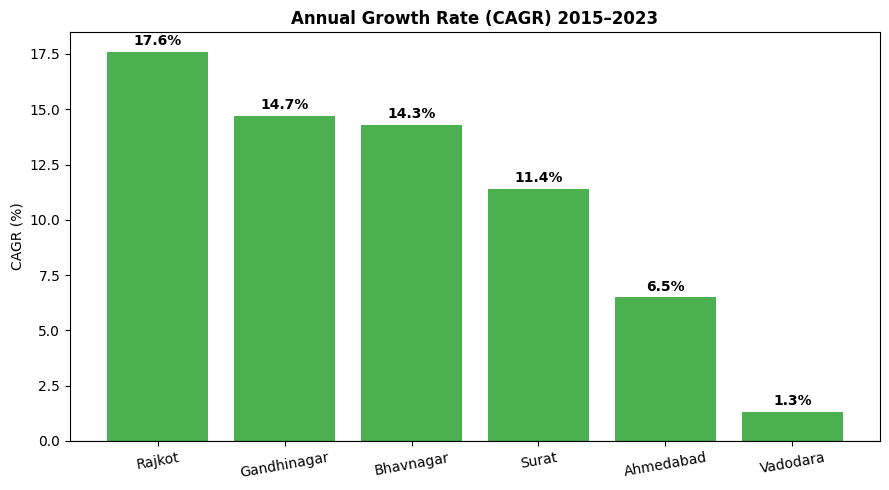

Chart saved to reports/31_district_growth_rates.png


In [13]:
print("DISTRICT GROWTH ANALYSIS (2015 vs 2023):")
print("-" * 55)

growth_data = []

for dist in TOP_DISTRICTS:
    sub = ts[ts["distName"] == dist].set_index("startProjectYear")
    if 2015 in sub.index and 2023 in sub.index:
        c2015 = sub.loc[2015, "project_count"]
        c2023 = sub.loc[2023, "project_count"]
        growth_pct = ((c2023 - c2015) / c2015) * 100
        cagr = ((c2023 / c2015) ** (1/8) - 1) * 100
        growth_data.append({
            "District": dist,
            "2015": c2015,
            "2023": c2023,
            "Growth %": round(growth_pct, 1),
            "CAGR %": round(cagr, 1)
        })
        print(f"  {dist:<15}  2015: {c2015:>4}  ->  2023: {c2023:>4}  "
              f"Growth: {growth_pct:>+6.1f}%   CAGR: {cagr:.1f}%/yr")

growth_df = pd.DataFrame(growth_data).sort_values("CAGR %", ascending=False)

# Plot growth rates
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#4CAF50" if v > 0 else "#EF5350" for v in growth_df["CAGR %"]]
bars = ax.bar(growth_df["District"], growth_df["CAGR %"], color=colors)
for bar, val in zip(bars, growth_df["CAGR %"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", fontweight="bold")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Annual Growth Rate (CAGR) 2015–2023", fontsize=12, fontweight="bold")
ax.set_ylabel("CAGR (%)")
ax.tick_params(axis="x", rotation=10)
plt.tight_layout()
plt.savefig("../reports/31_district_growth_rates.png", dpi=150)
plt.show()
print("Chart saved to reports/31_district_growth_rates.png")

## Cell 14 — COVID Impact Analysis
2020 shows a dip in most districts due to COVID-19. Let's visualise it.

COVID IMPACT (2019 vs 2020 vs 2021):
----------------------------------------------------
  Ahmedabad        2019: 494  2020: 332(-32.8%)  2021: 572(+72.3%)
  Vadodara         2019: 229  2020: 225( -1.7%)  2021: 297(+32.0%)
  Surat            2019: 154  2020: 101(-34.4%)  2021: 160(+58.4%)
  Rajkot           2019: 335  2020: 217(-35.2%)  2021: 194(-10.6%)
  Gandhinagar      2019: 158  2020: 139(-12.0%)  2021: 141( +1.4%)
  Bhavnagar        2019:  68  2020:  53(-22.1%)  2021:  60(+13.2%)


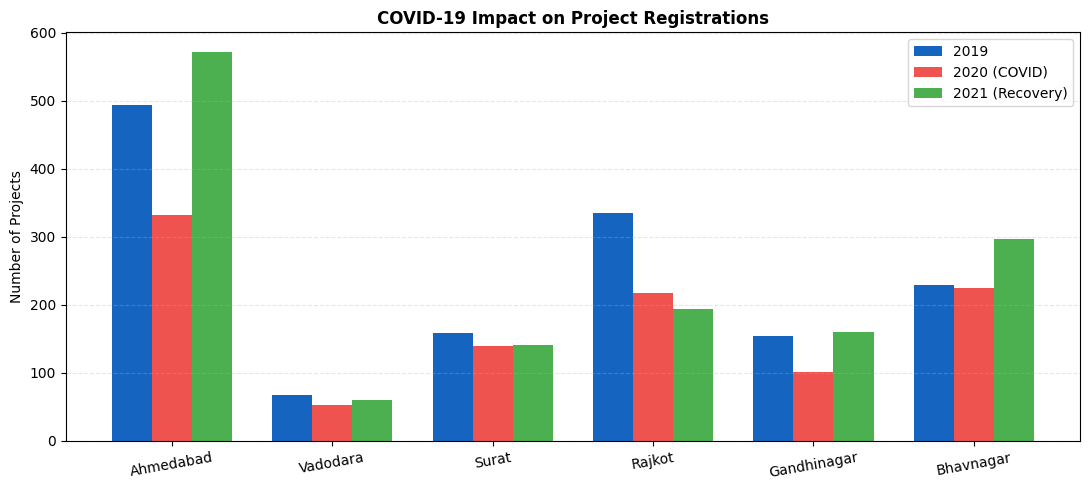

Chart saved to reports/32_covid_impact.png


In [14]:
# Compare 2019, 2020, 2021 for each district
print("COVID IMPACT (2019 vs 2020 vs 2021):")
print("-" * 52)

for dist in TOP_DISTRICTS:
    sub = ts[ts["distName"] == dist].set_index("startProjectYear")["project_count"]
    y19 = sub.get(2019, 0)
    y20 = sub.get(2020, 0)
    y21 = sub.get(2021, 0)
    drop = ((y20 - y19) / y19 * 100) if y19 > 0 else 0
    recovery = ((y21 - y20) / y20 * 100) if y20 > 0 else 0
    print(f"  {dist:<15}  2019:{y19:>4}  2020:{y20:>4}({drop:>+5.1f}%)  "
          f"2021:{y21:>4}({recovery:>+5.1f}%)")

# Plot 2019-2021 comparison
sub_2019_21 = ts[ts["startProjectYear"].isin([2019, 2020, 2021]) &
                  ts["distName"].isin(TOP_DISTRICTS)]

pivot = sub_2019_21.pivot(index="distName", columns="startProjectYear",
                           values="project_count").fillna(0)

x     = np.arange(len(TOP_DISTRICTS))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width, pivot[2019], width, label="2019", color="#1565C0")
ax.bar(x,         pivot[2020], width, label="2020 (COVID)", color="#EF5350")
ax.bar(x + width, pivot[2021], width, label="2021 (Recovery)", color="#4CAF50")

ax.set_xticks(x)
ax.set_xticklabels(TOP_DISTRICTS, rotation=10)
ax.set_title("COVID-19 Impact on Project Registrations", fontsize=12, fontweight="bold")
ax.set_ylabel("Number of Projects")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/32_covid_impact.png", dpi=150)
plt.show()
print("Chart saved to reports/32_covid_impact.png")

## Cell 15 — Forecast Summary Table
Combine all district forecasts into one clean table.

In [15]:
print("=" * 65)
print("  FORECAST SUMMARY — PROJECT COUNT (2024-2026)")
print("=" * 65)
print(f"  {'District':<15}  {'2023 (actual)':>14}  {'2024':>8}  {'2025':>8}  {'2026':>8}")
print("-" * 65)

all_forecast_rows = []

for dist in TOP_DISTRICTS:
    d           = forecasts[dist]
    actual_2023 = int(d["counts"][-1])
    fc_2024     = round(d["future_fc"][0])
    fc_2025     = round(d["future_fc"][1])
    fc_2026     = round(d["future_fc"][2])

    print(f"  {dist:<15}  {actual_2023:>14}  {fc_2024:>8}  {fc_2025:>8}  {fc_2026:>8}")

    all_forecast_rows.append({
        "district"     : dist,
        "actual_2023"  : actual_2023,
        "forecast_2024": fc_2024,
        "forecast_2025": fc_2025,
        "forecast_2026": fc_2026,
    })

print("-" * 65)
forecast_summary_df = pd.DataFrame(all_forecast_rows)
print("\nNote: Forecasts are ARIMA trend-based estimates.")

  FORECAST SUMMARY — PROJECT COUNT (2024-2026)
  District          2023 (actual)      2024      2025      2026
-----------------------------------------------------------------
  Ahmedabad                   462       377       444       391
  Vadodara                    193       188       185       182
  Surat                       254       272       277       279
  Rajkot                      139       144       146       147
  Gandhinagar                 180       192       204       216
  Bhavnagar                    76        69        75        70
-----------------------------------------------------------------

Note: Forecasts are ARIMA trend-based estimates.


## Cell 16 — Save Forecasts to CSV

In [17]:
os.makedirs("../data/predictions", exist_ok=True)

# Save district forecasts
all_rows = []
for dist in TOP_DISTRICTS:
    hist = pd.DataFrame({
        "district": dist,
        "year": forecasts[dist]["years"],
        "project_count": forecasts[dist]["counts"],
        "type": "historical",
    })

    fc_fut = pd.DataFrame({
        "district": dist,
        "year": forecasts[dist]["future_years"],
        "project_count": np.clip(forecasts[dist]["future_fc"], 0, None).round(0).astype(int),
        "type": "forecast",
    })

    all_rows.append(hist)
    all_rows.append(fc_fut)

final_df = pd.concat(all_rows, ignore_index=True)
final_df.to_csv("../data/predictions/forecasts.csv", index=False)

# Save summary
forecast_summary_df.to_csv("../data/predictions/forecast_summary.csv", index=False)

print("Forecasts saved!")
print("  data/predictions/forecasts.csv")
print("  data/predictions/forecast_summary.csv")
print(f"  Total rows : {len(final_df)}")

Forecasts saved!
  data/predictions/forecasts.csv
  data/predictions/forecast_summary.csv
  Total rows : 95


## Cell 17 — Module 3 Final Summary

In [19]:
print()
print("=" * 58)
print("  MODULE 3 — MARKET GROWTH FORECASTING — SUMMARY")
print("=" * 58)
print()
print("  Models used  :")
print("    Prophet — district-level project count forecast")
print("    ARIMA   — Gujarat state total forecast")
print()
print("  Districts forecasted :", TOP_DISTRICTS)
print()
print("  Forecast horizon     : 2024, 2025, 2026  (3 years)")
print()
print("  Key findings :")

for dist in TOP_DISTRICTS:
    fc = forecasts[dist]["future_fc"]
    f24 = max(0, float(fc[0]))
    f26 = max(0, float(fc[2]))
    trend = "growing" if f26 > f24 else "declining"
    print(f"    {dist:<15}  trend: {trend}  (2024: {f24:.0f} -> 2026: {f26:.0f} projects)")

print()
print("  SAVED FILES:")
print("    data/predictions/forecasts.csv")
print("    data/predictions/forecast_summary.csv")
print("    reports/27_district_trends_overview.png")
print("    reports/28_prophet_forecasts_districts.png")
print("    reports/29_arima_gujarat_forecast.png")
print("    reports/30_investment_forecasts_districts.png")
print("    reports/31_district_growth_rates.png")
print("    reports/32_covid_impact.png")
print()
print("  Next: 07_module4_clustering.ipynb")
print("=" * 58)


  MODULE 3 — MARKET GROWTH FORECASTING — SUMMARY

  Models used  :
    Prophet — district-level project count forecast
    ARIMA   — Gujarat state total forecast

  Districts forecasted : ['Ahmedabad', 'Vadodara', 'Surat', 'Rajkot', 'Gandhinagar', 'Bhavnagar']

  Forecast horizon     : 2024, 2025, 2026  (3 years)

  Key findings :
    Ahmedabad        trend: growing  (2024: 377 -> 2026: 391 projects)
    Vadodara         trend: declining  (2024: 188 -> 2026: 182 projects)
    Surat            trend: growing  (2024: 272 -> 2026: 279 projects)
    Rajkot           trend: growing  (2024: 144 -> 2026: 147 projects)
    Gandhinagar      trend: growing  (2024: 192 -> 2026: 216 projects)
    Bhavnagar        trend: growing  (2024: 69 -> 2026: 70 projects)

  SAVED FILES:
    data/predictions/forecasts.csv
    data/predictions/forecast_summary.csv
    reports/27_district_trends_overview.png
    reports/28_prophet_forecasts_districts.png
    reports/29_arima_gujarat_forecast.png
    reports/30